# Diabetes Model

### Entire flow of building model:
- Library imports
- Loading the dataset
- Dataset description
- Missing Values check
- Merging the files
- Data cleaning
- Explanatory Data Analysis (EDA)
- Feature Engineering 
- Training ML Models
- Evaluating all the models' performances
- Creating `.pkl` file from the best performing model
- Creating prediction function using the `.pkl` file that can be integrated with the frontend/backend
- Finally testing the prediction function for all the possible labels

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import pickle

In [2]:
# %pip install 

In [3]:
# loading the data 
# converting from .xpt to df

# path = "../data/raw"
# path = "ml-diabetes/data/raw"

demo = pd.read_sas("../data/raw/DEMO_J.xpt")
bmi = pd.read_sas("../data/raw/BMX_J.xpt")
glu = pd.read_sas("../data/raw/GLU_J.xpt")
a1c = pd.read_sas("../data/raw/GHB_J.xpt")
diq = pd.read_sas("../data/raw/DIQ_J.xpt")

In [4]:
print(demo.shape)
print(bmi.shape)
print(glu.shape)
print(a1c.shape)
print(diq.shape)

print("==== Description: ====")
# print("----- Demo: -----")
# print(demo.describe)
# print("----- BMI: -----")
# print(bmi.describe)
# print("----- Glucose: -----")
# print(glu.describe)
# print("----- A1C: -----")
# print(a1c.describe)
# print("----- DIQ: -----")
# print(diq.describe)

print("==== Info: ====")
print("----- Demo: -----")
print(demo.info())
print("----- BMI: -----")
print(bmi.info())
print("----- Glucose: -----")
print(glu.info())
print("----- A1C: -----")
print(a1c.info())
print("----- DIQ: -----")
print(diq.info())


(9254, 46)
(8704, 21)
(3036, 4)
(6401, 2)
(8897, 54)
==== Description: ====
==== Info: ====
----- Demo: -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9254 entries, 0 to 9253
Data columns (total 46 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      9254 non-null   float64
 1   SDDSRVYR  9254 non-null   float64
 2   RIDSTATR  9254 non-null   float64
 3   RIAGENDR  9254 non-null   float64
 4   RIDAGEYR  9254 non-null   float64
 5   RIDAGEMN  597 non-null    float64
 6   RIDRETH1  9254 non-null   float64
 7   RIDRETH3  9254 non-null   float64
 8   RIDEXMON  8704 non-null   float64
 9   RIDEXAGM  3433 non-null   float64
 10  DMQMILIZ  6004 non-null   float64
 11  DMQADFC   561 non-null    float64
 12  DMDBORN4  9254 non-null   float64
 13  DMDCITZN  9251 non-null   float64
 14  DMDYRSUS  1948 non-null   float64
 15  DMDEDUC3  2306 non-null   float64
 16  DMDEDUC2  5569 non-null   float64
 17  DMDMARTL  5569 non-null   float64
 18

## Dataset Description

- The NHANES dataset contains multiple components, each with a different number of participants and variables. 
- For e.g., the demographics dataset contains over 9000 records, while laboratory datasets such as glucose have fewer records because not all participants undergo every test. 
- This results in missing values across different files. 
- Therefore, only a subset of participants with complete information across all required variables is used after merging the datasets. 
- Key variables selected for this project include age, gender, BMI, blood glucose, HbA1c, and diabetes status, as they are directly related to diabetes prediction.

## File and Columns Explanation:

Before moving forward to Data Cleaning, it is important to understand each of columns in each of the files

#### DEMO (Demographics file)
- Out of all the 46 cols, on these 3 are important:
    - `SEQN` (person id)
    - `RIDAGEYR` (Age)
    - `RIAGENDER` (Gender: 1=Male; 2=Female)

#### BMI (Body Measures file)
- Important cols:
    - `SEQN` (person id)
    - `BMXBMI` (Body Mass Index)

#### GLU (Glucose file)
- Important cols:
    - `SEQN` (person id)
    - `LBXGLU` (Blood Glucose ----VIMP)

#### A1C (A1C file)
- Important cols:
    - `SEQN` (person id)
    - `LBXGH` (Hba1c: avg glucose over time)

#### DIQ (Diabetes Questionnaire file)
- Important cols:
    - `SEQN` (person id)
    - `DIQ010` (Diabetes diagnosis; 1=Yes, has diabetes; 0=No; other vals are ignorable)


## Missing Values check 

#### In DEMO 
- no values are missing for any required cols

#### In BMX 
- no values are missing for any required cols

#### In GLU 
- `LBXGLU` 2891 non-null out of 3036 entries: this indicates missing data
- Conclusion: Some people didn’t take lab tests

#### In A1C 
- `LBXGH` 6045 non-null out of 6401 entries: this indicates missing data
- Conclusion: Some people didn’t take lab tests

#### In DIQ 
- no values are missing for any required cols

#### Other Observations:
- Total entries in DEMO = 9254 and GLU = 3036: this indicates that only a subset of people did fasting glucose tests
- So after merging datasets (by doing inner join), dataset will shrink to people who have all the datasets


In [5]:
print(demo[["SEQN", "RIDAGEYR", "RIAGENDR"]].head())
print(bmi[["SEQN", "BMXBMI"]].head())
print(glu[["SEQN", "LBXGLU"]].head())
print(a1c[["SEQN", "LBXGH"]].head())
print(diq[["SEQN", "DIQ010"]].head())

      SEQN  RIDAGEYR  RIAGENDR
0  93703.0       2.0       2.0
1  93704.0       2.0       1.0
2  93705.0      66.0       2.0
3  93706.0      18.0       1.0
4  93707.0      13.0       1.0
      SEQN  BMXBMI
0  93703.0    17.5
1  93704.0    15.7
2  93705.0    31.7
3  93706.0    21.5
4  93707.0    18.1
      SEQN  LBXGLU
0  93708.0   122.0
1  93711.0   107.0
2  93717.0    91.0
3  93718.0    89.0
4  93719.0    86.0
      SEQN  LBXGH
0  93705.0    6.2
1  93706.0    5.2
2  93707.0    5.6
3  93708.0    6.2
4  93709.0    6.3
      SEQN  DIQ010
0  93703.0     2.0
1  93704.0     2.0
2  93705.0     2.0
3  93706.0     2.0
4  93707.0     2.0


## Merging the files

##### Before Merge:
- DEMO has 9254 rows
- GLU has 3036 rows

In [6]:
# Merging files on person id
df = demo.merge(bmi, on="SEQN", how="inner") \
         .merge(glu, on="SEQN", how="inner") \
         .merge(a1c, on="SEQN", how="inner") \
         .merge(diq, on="SEQN", how="inner")

print("Merged shape:", df.shape)
df.head()

Merged shape: (3036, 123)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DIQ300D,DID310S,DID310D,DID320,DID330,DID341,DID350,DIQ350U,DIQ360,DIQ080
0,93708.0,10.0,2.0,2.0,66.0,NaN,5.0,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93711.0,10.0,2.0,1.0,56.0,NaN,5.0,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93717.0,10.0,2.0,1.0,22.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,93718.0,10.0,2.0,1.0,45.0,NaN,4.0,4.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,93719.0,10.0,2.0,2.0,13.0,NaN,3.0,3.0,2.0,159.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### After Merge:

- only the rows where person id exists in all files are fetched
- main focus is to have as many rows as in GLU which is 3036 
- (People who have glucose data) AND operation (everything else)
- total 123 cols because (most of them are not needed but will work on those in the cleaning section):
    - DEMO has 46 cols
    - BMX has 21 cols
    - GLU has 4 cols
    - A1C has 2 cols
    - DIQ has 54 cols


In [7]:
# Missing values will be dealt in the cleaning section
df.isnull().sum()

SEQN           0
SDDSRVYR       0
RIDSTATR       0
RIAGENDR       0
RIDAGEYR       0
            ... 
DID341      2603
DID350      2603
DIQ350U     2689
DIQ360      2602
DIQ080      2602
Length: 123, dtype: int64

In [8]:
# Sanity check
df[["SEQN", "RIDAGEYR", "BMXBMI", "LBXGLU", "LBXGH", "DIQ010"]].head(10)

,SEQN,RIDAGEYR,BMXBMI,LBXGLU,LBXGH,DIQ010
0,93708.0,66.0,23.7,122.0,6.2,3.0
1,93711.0,56.0,21.3,107.0,5.7,2.0
2,93717.0,22.0,24.5,91.0,5.1,2.0
3,93718.0,45.0,22.0,89.0,5.7,2.0
4,93719.0,13.0,26.0,86.0,5.0,2.0
5,93721.0,60.0,35.9,104.0,5.2,2.0
6,93722.0,60.0,23.8,101.0,5.8,2.0
7,93731.0,20.0,27.6,98.0,4.9,2.0
8,93732.0,72.0,21.3,NaN,NaN,2.0
9,93735.0,52.0,35.1,83.0,5.0,2.0


#### In the Sanity check

- Values look realistic, and the null values in `LBXGLU` and `LBXGH` can be handled in the cleaning section
- in the DIQ010: there's "3.0", which means apart from Yes and No, 3 means borderline for diabetes (can be handled in cleaning section)

## Data Cleaning

#### Tasks:

- remove the 3rd category in the diabetes col
- convert values to binary for diabetes and gender col
- drop rows which has missing data
- drop the rows where age is less then 18 (after implementing the above 3, in df.head() output, i saw age "13")

In [9]:
df = df[["RIDAGEYR", "RIAGENDR", "BMXBMI", "LBXGLU", "LBXGH", "DIQ010"]]

In [10]:
# Renaming the col names
df.rename(columns={
    "RIDAGEYR": "age",
    "RIAGENDR": "gender",
    "BMXBMI": "bmi",
    "LBXGLU": "glucose",
    "LBXGH": "a1c",
    "DIQ010": "diabetes_raw"
}, inplace=True)

Since there are 3 categories in the DIQ010 section, removing the 3rd target value and keeping only 1 and 2 as the indication for borderline/prediabetic can be done from the Glucose and A1c

In [11]:
# dropping the 3rd target
# and changing the target values from 1,2 to 0,1
df = df[df["diabetes_raw"].isin([1, 2])]
df["diabetes"] = df["diabetes_raw"].apply(lambda x: 1 if x == 1 else 0)
df.drop(columns=["diabetes_raw"], inplace=True)
df["diabetes"].value_counts()

diabetes
0    2512
1     435
Name: count, dtype: int64

In [12]:
# now dealing with null values, and as they are not needed, droping those
df = df.dropna()

In [13]:
# converting the values for gender from 1,2 to 0,1
df["gender"] = df["gender"].map({1: 0, 2: 1})

In [14]:
# considering only the rows where age>=18
df = df[df["age"] >= 18]

In [15]:
print("==== first 5 vals: ====")
print(df.head())
print("==== Shape: ====")
print(df.shape)
print("==== Info: ====")
print(df.info())
print("==== Describe: ====")
print(df.describe())

==== first 5 vals: ====
    age  gender   bmi  glucose  a1c  diabetes
1  56.0       0  21.3    107.0  5.7         0
2  22.0       0  24.5     91.0  5.1         0
3  45.0       0  22.0     89.0  5.7         0
5  60.0       1  35.9    104.0  5.2         0
6  60.0       1  23.8    101.0  5.8         0
==== Shape: ====
(2408, 6)
==== Info: ====
<class 'pandas.core.frame.DataFrame'>
Index: 2408 entries, 1 to 3035
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2408 non-null   float64
 1   gender    2408 non-null   int64  
 2   bmi       2408 non-null   float64
 3   glucose   2408 non-null   float64
 4   a1c       2408 non-null   float64
 5   diabetes  2408 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 131.7 KB
None
==== Describe: ====
               age       gender          bmi      glucose          a1c  \
count  2408.000000  2408.000000  2408.000000  2408.000000  2408.000000   
mean     49.903654 

## Explanatory Data Analysis (EDA)

In [16]:
# checking stats
df.describe()

,age,gender,bmi,glucose,a1c,diabetes
count,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000
mean,49.903654,0.519934,29.605440,113.595930,5.848007,0.168189
std,18.435187,0.499706,7.408447,37.317109,1.116286,0.374112
min,18.000000,0.000000,15.500000,47.000000,4.100000,0.000000
25%,34.000000,0.000000,24.500000,96.000000,5.300000,0.000000
50%,52.000000,1.000000,28.300000,103.500000,5.600000,0.000000
75%,64.000000,1.000000,33.500000,115.000000,6.000000,0.000000
max,80.000000,1.000000,86.200000,421.000000,15.200000,1.000000


### Stats Description

- age: min age shows 18 and max is 80 and the spread looks fair
- gender: min is 0 and max is 1 that means only 2 possible values as per the raw data
- glucose: mean looks reasonable
- a1c: mean looks reasonable
- diabetes: min and max values are 0 and 1 respectively


In [17]:
# checking class balance
df["diabetes"].value_counts()

diabetes
0    2003
1     405
Name: count, dtype: int64

#### Class Balance Observation

- The dataset shows an imbalance between diabetic and non-diabetic cases, with significantly more non-diabetic individuals. 
- This class imbalance may affect model performance, as the model could become biased toward predicting the majority class. 
- I will be working on this during the model evaluation.

### Distribution Plots (Histogram)

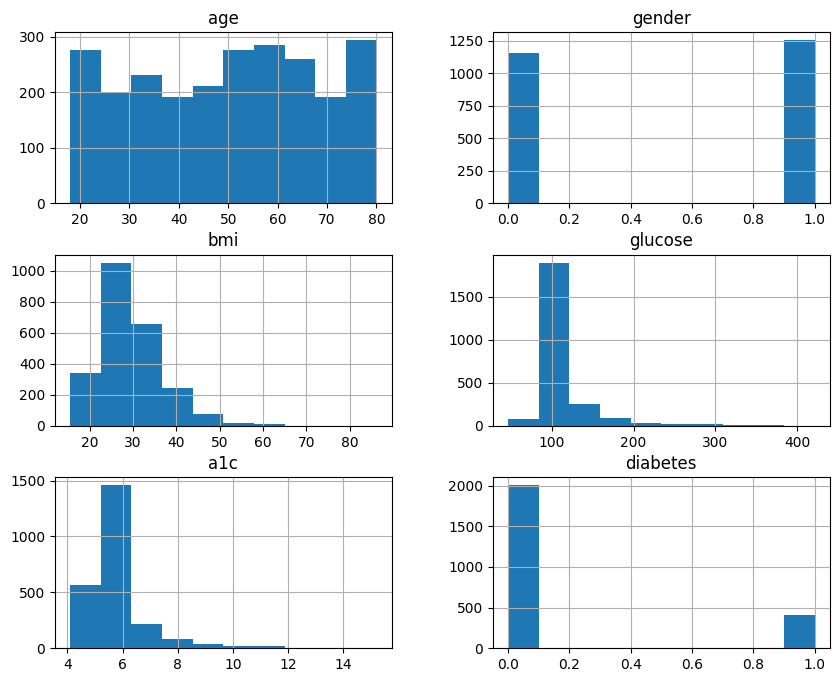

In [18]:
df.hist(figsize=(10,8))
plt.show()

#### Histogram Observations

- The distribution plots show how the key features are spread across the dataset. 
- Age appears to be fairly spread out across adult participants, indicating a diverse sample. 
- BMI values are mostly concentrated in the range of 20 to 35, with some higher values indicating overweight or obese individuals.
- Glucose and HbA1c values are slightly skewed, with most individuals having normal ranges and a smaller group showing higher values. 
- This suggests that while most participants are non-diabetic, there is a noticeable portion of individuals with elevated health risk indicators.

### Correlation Heatmap

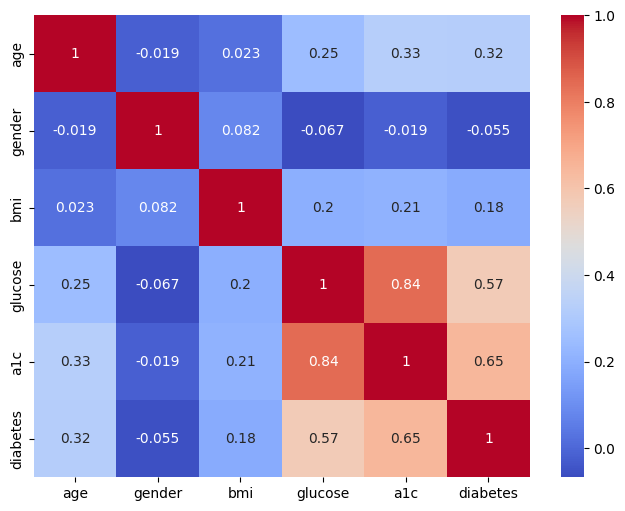

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

#### Heatmap Observations

- The correlation heatmap highlights the relationships between different features and diabetes status. 
- Glucose and HbA1c show the strongest positive correlation with diabetes, indicating that higher values are strongly associated with diabetic individuals. 
- BMI and age also show moderate positive relationships with diabetes, suggesting they contribute to risk but are not as strong predictors as glucose and HbA1c. 
- Gender shows little to no strong correlation, indicating it may have a smaller impact on prediction compared to other features.

### Other Columns vs Diabetes Column (Other cols vs Response col)

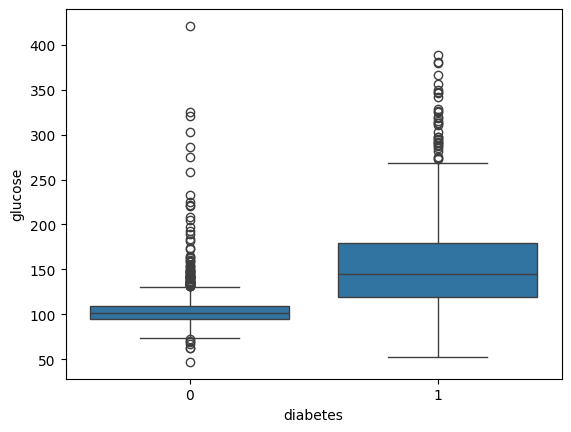

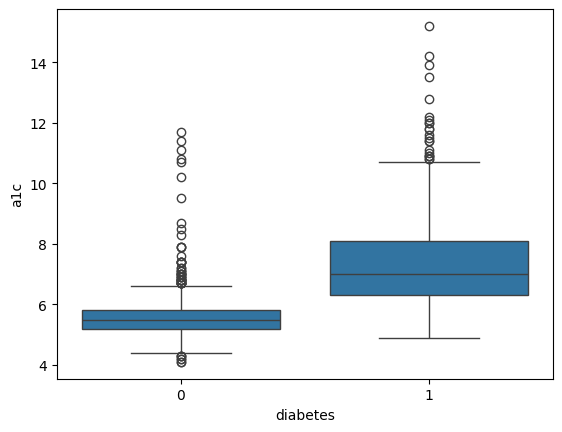

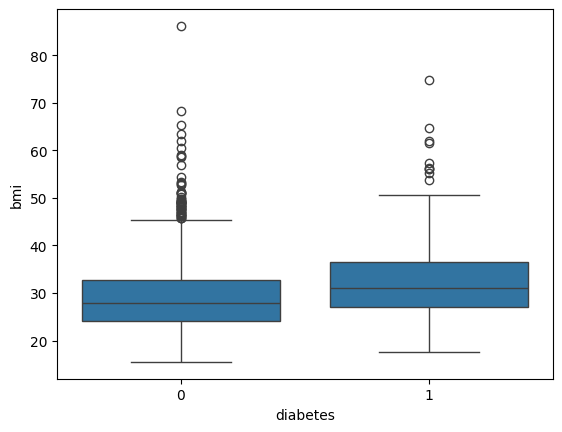

In [20]:
sns.boxplot(x="diabetes", y="glucose", data=df)
plt.show()

sns.boxplot(x="diabetes", y="a1c", data=df)
plt.show()

sns.boxplot(x="diabetes", y="bmi", data=df)
plt.show()

#### Boxplot Observations

- <b>Glucose vs Diabetes</b>: The boxplot comparing glucose levels across diabetes categories shows a clear separation between diabetic and non-diabetic individuals. People with diabetes tend to have significantly higher glucose levels, while non-diabetic individuals mostly fall within a lower range. This confirms that glucose is a strong predictor of diabetes.

- <b>A1c vs Diabetes</b>: The HbA1c boxplot shows an even stronger distinction between the two groups. Diabetic individuals consistently have higher HbA1c levels, reflecting long-term elevated blood sugar. This makes HbA1c one of the most important features for predicting diabetes.

- <b>BMI vs Diabetes</b>: The BMI boxplot shows that individuals with diabetes tend to have slightly higher BMI values compared to non-diabetic individuals. However, the separation is not as strong as seen with glucose or HbA1c, indicating that BMI contributes to diabetes risk but is not a primary indicator on its own.


### EDA Insights

- Overall, the exploratory data analysis shows that glucose and HbA1c are the strongest indicators of diabetes, with clear differences between diabetic and non-diabetic individuals. 
- BMI and age also contribute to risk but with less distinction. 
- The dataset also shows some class imbalance, which may impact model performance. 
- These insights will guide the feature selection and modeling approach in the next steps.

## Feature Engineering

BMI categories
- Underwight: < 18.5 -------------> 0 
- Normal: 18.5 - 24.9 ------------> 1
- Overweight: 25.0 - 29.9 --------> 2
- Obesity: > 30.0 ----------------> 3
 

In [21]:
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3]
)

Blood Sugar Levels

- Normal: 99 mg/dL or lower (overnight fasting)
- Abnormal: 100 mg/dL or higher
- Prediabetic: 100-125 mg/dL 
- Type 2 Diabetes: 126 mg/dL or higher

Here, glucose values > 126 would be considered as risky

In [22]:
df["high_glucose"] = df["glucose"].apply(lambda x: 1 if x >= 126 else 0)

A1C Levels
- Normal: below 5.7%
- Prediabetes: 5.7% to 6.4%
- Diabetes: 6.5% or above

Here, A1c level above 6.5 will be flagged as diabetes

In [23]:
df["high_a1c"] = df["a1c"].apply(lambda x: 1 if x >= 6.5 else 0)

Categorizing Age group (might remove later..)

In [24]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 45, 60, 100],
    labels=[0, 1, 2, 3],
    include_lowest=True
)

In [25]:
# converting the categorical cols (bmi cat, age group) to numeric
# df["bmi_category"] = df["bmi_category"].astype(int)
# df["age_group"] = df["age_group"].astype(int)
df["bmi_category"] = df["bmi_category"].cat.codes
df["age_group"] = df["age_group"].cat.codes

### Feature Engineering explanation

## Training/Testing ML Models

In [26]:
# since the response column is categorical, I will be using Classification Algorithms to train, test and evaluate

# preparing the data
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [27]:
# now train, test, split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
# also, both the values in the response column were not balanced, so handling it here..
# normalizing it (converting them from 0-1)
y.value_counts(normalize=True)

diabetes
0    0.831811
1    0.168189
Name: proportion, dtype: float64

## Model Evaluation & Selecting Best Model

### Logistic Regression Model

In [29]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
y_pred_lr = lr.predict(X_test)

In [31]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       400
           1       0.86      0.68      0.76        82

    accuracy                           0.93       482
   macro avg       0.90      0.83      0.86       482
weighted avg       0.92      0.93      0.92       482

ROC-AUC: 0.8302134146341464


### Random Forest Model

In [32]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
y_pred_rf = rf.predict(X_test)

In [34]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       400
           1       0.79      0.71      0.75        82

    accuracy                           0.92       482
   macro avg       0.87      0.83      0.85       482
weighted avg       0.92      0.92      0.92       482

ROC-AUC: 0.8349085365853659


### K-Nearest Neighbors Model

In [35]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN")
print(classification_report(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_knn))

KNN
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       400
           1       0.80      0.55      0.65        82

    accuracy                           0.90       482
   macro avg       0.86      0.76      0.80       482
weighted avg       0.89      0.90      0.89       482

ROC-AUC: 0.7606402439024391


### Gradient Boosting Model

In [36]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_gb))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       400
           1       0.78      0.72      0.75        82

    accuracy                           0.92       482
   macro avg       0.86      0.84      0.85       482
weighted avg       0.91      0.92      0.92       482

ROC-AUC: 0.8385060975609756


### XGBoost Model

In [37]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))

C:\Users\eshik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGBoost
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       400
           1       0.76      0.70      0.73        82

    accuracy                           0.91       482
   macro avg       0.85      0.83      0.84       482
weighted avg       0.91      0.91      0.91       482

ROC-AUC: 0.825060975609756


### Comparing the Models

- <b>Precision</b>: When model says diabetic, how often is it right?
- <b>Recall</b>: How many actual diabetics did we catch?
- <b>F1-score</b>: balance of precision & recall
- <b>ROC-AUC</b>: overall ability to distinguish classes

In [38]:
results = {
    "Model": ["Logistic", "Random Forest", "KNN", "Gradient Boosting", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_pred_knn),
        roc_auc_score(y_test, y_pred_gb),
        roc_auc_score(y_test, y_pred_xgb)
    ]
}

pd.DataFrame(results)

,Model,ROC-AUC
0,Logistic,0.830213
1,Random Forest,0.834909
2,KNN,0.760640
3,Gradient Boosting,0.838506
4,XGBoost,0.825061


### Model Comparison and Best Performing Model

- Multiple machine learning models were trained and evaluated using ROC-AUC as the primary performance metric. 
- Among all models, Gradient Boosting achieved the highest ROC-AUC score, indicating the best overall performance in distinguishing between diabetic and non-diabetic individuals. 
- Random Forest also performed well and produced comparable results, highlighting the effectiveness of ensemble methods for this dataset. 
- Logistic Regression showed strong performance despite being a simpler model, suggesting that the relationship between features such as glucose and HbA1c and diabetes is relatively linear. 
- On the other hand, K-Nearest Neighbors performed the weakest, likely due to its sensitivity to data distribution and feature scaling. 
- XGBoost performed reasonably well but did not outperform Gradient Boosting, possibly due to the lack of hyperparameter tuning. 
- Overall, Gradient Boosting was selected as the final model due to its superior performance.

## Creating .pkl file from the Trained Model

In [39]:
with open("../models/diabetes_model.pkl", "wb") as f:
    pickle.dump(gb, f)

In [ ]:
# prediction function

def predict_diabetes(age, gender, bmi, glucose, a1c):
    
    # Feature engineering (same as training)
    bmi_category = 0
    if bmi < 18.5:
        bmi_category = 0
    elif bmi < 25:
        bmi_category = 1
    elif bmi < 30:
        bmi_category = 2
    else:
        bmi_category = 3

    high_glucose = 1 if glucose >= 126 else 0
    high_a1c = 1 if a1c >= 6.5 else 0

    if age < 30:
        age_group = 0
    elif age < 45:
        age_group = 1
    elif age < 60:
        age_group = 2
    else:
        age_group = 3

    

    features = pd.DataFrame([{
        "age": age,
        "gender": gender,
        "bmi": bmi,
        "glucose": glucose,
        "a1c": a1c,
        "bmi_category": bmi_category,
        "high_glucose": high_glucose,
        "high_a1c": high_a1c,
        "age_group": age_group
    }])

    # predict
    prediction = gb.predict(features)[0]
    probability = gb.predict_proba(features)[0][1]

    return prediction, probability

In [42]:
# testing it
pred, prob = predict_diabetes(50, 1, 32, 140, 7.0)

print("Prediction:", pred)
print("Probability:", prob)


pred, prob = predict_diabetes(
    age=25,
    gender=0,
    bmi=22,   
    glucose=90,
    a1c=5.2
)

print("Prediction:", pred)
print("Probability:", prob)

Prediction: 1
Probability: 0.5789829389520421
Prediction: 0
Probability: 0.005704389484909059


## References

- Centers for Disease Control and Prevention. (2023). National Health and Nutrition Examination Survey (NHANES). Retrieved from https://wwwn.cdc.gov/nchs/nhanes/
- Centers for Disease Control and Prevention. (2017). A data-driven approach to predicting diabetes risk. Retrieved from https://www.cdc.gov/pcd/issues/2017/16_0244.htm
- American Diabetes Association. (2022). Classification and diagnosis of diabetes: Standards of medical care in diabetes. Diabetes Care, 45(Supplement 1), S17–S38. Retrieved from https://diabetesjournals.org/care/article/45/Supplement_1/S17/138925/2-Classification-and-Diagnosis-of-Diabetes
- World Health Organization. (2021). Diabetes. Retrieved from https://www.who.int/news-room/fact-sheets/detail/diabetes
- Zou, Q., Qu, K., Luo, Y., Yin, D., Ju, Y., & Tang, H. (2018). Predicting diabetes mellitus with machine learning techniques. Frontiers in Genetics, 9, 515. Retrieved from https://www.frontiersin.org/journals/genetics/articles/10.3389/fgene.2018.00515/full
- Kavakiotis, I., Tsave, O., Salifoglou, A., et al. (2017). Machine learning and data mining methods in diabetes research. Computational and Structural Biotechnology Journal, 15, 104–116. Retrieved from https://www.sciencedirect.com/science/article/pii/S2001037016300733
- Reading .xpt files: https://pandas.pydata.org/docs/reference/api/pandas.read_sas.html
- BMI categories: https://www.cdc.gov/bmi/adult-calculator/bmi-categories.html 
- Glucose level: https://www.ynhhs.org/articles/what-is-healthy-blood-sugar 
- A1c levels: https://www.cdc.gov/diabetes/diabetes-testing/prediabetes-a1c-test.html